# Домашнее задание 8. Мониторинг

Прослеживаемость конвейера (и кода, и данных) должна закладываться **до проектирования** (в идеале, на основе синтезированного трафика от системы нагрузочного тестирования Locust/k6s/ab/...).


## 1. Определить ключевые бизнес- и технические метрики для ML-системы

Чтобы разработка могла сдвинуться с мертвой точки, создайте сбаланисированное дерево метрик, которое бы учитывало точки зрения разных команд.


|Требования бизнеса|Требования разработчиков|Требования команды ML|Требования DevOps|
|------------------|------------------------|---------------------|-----------|
|Нужно увеличить выручку онлайн-кинотеатра|Нужен новый сервер |Нужен GPU      | Вы существующие мощности недогружаете |
|...пиковая нагрузка 10000 RPS|Нужно переходить на ClickHouse? |Сколько фильмов выводить для рекомендательной системы?      |Есть Postgres, он выдает 1000 RPS, потому что мы обернули Docker-in-Docker         |
|...и чтобы быстрый был|Нужно переписать бэкенд?|Нужно переходить на стримы? | Какое нужно время отклика? |
|...и чтобы надежный был| Сделать на Kubernetes? |Сделать на KubeFlow? | SLA 100% нет даже на бирже  |

Желательно использовать [adr-tools](https://github.com/npryce/adr-tools), чтобы записывать **причины**, по которым мы начали принимать решения и **риски**, из-за которых ML-система может работать не так, как ожидается.


*Ожидаемый артефакт: создающий диаграмму код в [ячейке](#scrollTo=y2v5KaAkw0zx)*

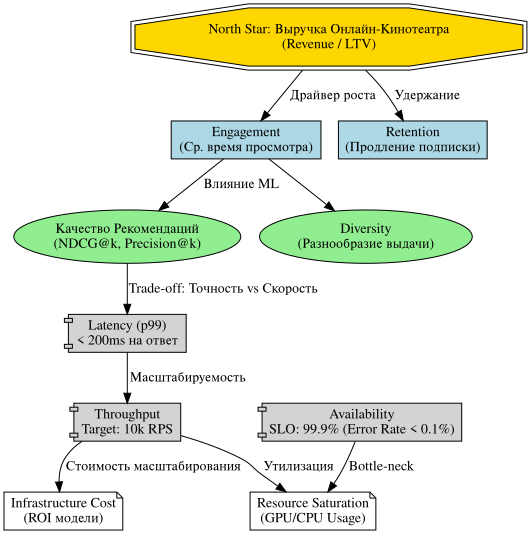

In [1]:
from graphviz import Digraph

dot = Digraph('ML_System_Metrics', comment='Balanced Metric Tree')
dot.attr(rankdir='TB', size='10')

dot.node('A', 'North Star: Выручка Онлайн-Кинотеатра\n(Revenue / LTV)', shape='doubleoctagon', style='filled', fillcolor='gold')

dot.node('B1', 'Engagement\n(Ср. время просмотра)', shape='box', style='filled', fillcolor='lightblue')
dot.node('B2', 'Retention\n(Продление подписки)', shape='box', style='filled', fillcolor='lightblue')

dot.node('C1', 'Качество Рекомендаций\n(NDCG@k, Precision@k)', shape='ellipse', style='filled', fillcolor='lightgreen')
dot.node('C2', 'Diversity\n(Разнообразие выдачи)', shape='ellipse', style='filled', fillcolor='lightgreen')

dot.node('D1', 'Latency (p99)\n< 200ms на ответ', shape='component', style='filled', fillcolor='lightgrey')
dot.node('D2', 'Throughput\nTarget: 10k RPS', shape='component', style='filled', fillcolor='lightgrey')
dot.node('D3', 'Availability\nSLO: 99.9% (Error Rate < 0.1%)', shape='component', style='filled', fillcolor='lightgrey')

dot.node('E1', 'Resource Saturation\n(GPU/CPU Usage)', shape='note')
dot.node('E2', 'Infrastructure Cost\n(ROI модели)', shape='note')

dot.edge('A', 'B1', label=' Драйвер роста')
dot.edge('A', 'B2', label=' Удержание')

dot.edge('B1', 'C1', label=' Влияние ML')
dot.edge('B1', 'C2')

dot.edge('C1', 'D1', label=' Trade-off: Точность vs Скорость')
dot.edge('D1', 'D2', label=' Масштабируемость')

dot.edge('D2', 'E1', label=' Утилизация')
dot.edge('D2', 'E2', label=' Стоимость масштабирования')
dot.edge('D3', 'E1', label=' Bottle-neck')

dot

## 2. Настроить мониторинг с использованием Prometheus, Grafana, MLflow


Желательно (но не обязательно) ознакомиться с инициативой по стандартизации [метрик](https://github.com/OpenSLO/OpenSLO), можно попробовать редактировать в [онлайн-редакторе](https://live.sloth.dev/?slo-spec=G4UwTgzglg9gdgLgAQCIAOYYFsQBcAWIArhAPTACMKAUBOMFAMYjIpYCedYDzNANgEMARiD4QE1JEhgB3OOFYdcIAVhpSwINDEXsYYAOakOXHiHVJcUBagBMNCHxjjJSAMRIA6iCQC+TmSQAMwEoPig4AyQACgBWAA943zgAEyQAFlsATgBKJAokTQBHIhAIXCQQUDB2fIAGBsKQErLcCBisrIA6LIBSHK7XAFokOFUWVGLS8oghgWBQwSEwqFx2CykYIQArEEYrUGROntcpFLLGMCg0K3hWAGFsLHgkAGUAGQB5JCEBOjSXvNFsIVmtgvokAAJAAq0IACk0WuUmhBtHA6BAuhskI4oBIpATKqA4G18YSCeBMGAAPotGrICBELDRMACZTRfC4XBoalTVrUlJEVm3ODUuiMeApCDUiVEEkAb22WwAvGxOPQmOYADQS87KgB+KDiXS6AB9MrkUABfADa8vlXRkERSsitVoAujkcqdybgYLg-LTSvScUyWWyQByuTy+eUBUK2bBReLJdLZQqlUJVSYNbxbfbHc7XR6vT6-OArJEyYSxjhkABZdivXMgSFQAz4ACiYCpACUIz6pEtRC5yQTGBGDPp2KwgWEQeE1tipAI4HB-Yn4KOx+4kJ9qjIrsokOcQkQ+BVXk4CG8vr4+BXQ1hnwIatI4JYmABrPDJNJoAQDB8cswDaQYdyfLBXxnVA2w7SoewhYUfBeAByHNuE1VDEWmNoUTRDFlyQACgOpEDcGrclhzESixzoapVhgki8BULBB3JTAiErAxqR-GClFY9irEYH9cDIh9QNoglqO3CD6PARjWEcAQRKIwllJEmV8FXeQ+FYNxyNmATVBQIA)


Принимая во внимание дерево метрик, выбранных в предыдущей [ячейке](#scrollTo=64bcf49d), нужно выбрать **одну** метрику и поставить ее на мониторинг.


*Ожидаемый артефакт: yaml в [ячейке](#scrollTo=Q0xhdA3Sw1XY) дашборд в [ячейке](#scrollTo=s7cw3qhud3Dx)*


In [2]:
%%writefile prometheus.yaml
global:
  scrape_interval: 5s
  evaluation_interval: 5s

scrape_configs:
  - job_name: 'ml_service'
    static_configs:
      - targets: ['ml-service:8000']
  - job_name: 'prometheus'
    static_configs:
      - targets: ['localhost:9090']

Writing prometheus.yaml


In [3]:
%%writefile grafana.yaml
apiVersion: 1

datasources:
  - name: Prometheus
    type: prometheus
    access: proxy
    orgId: 1
    url: http://prometheus:9090
    basicAuth: false
    isDefault: true
    editable: true

Writing grafana.yaml


## 3. Обнаружить деградацию модели и дрифт

Вспомните материалы [семинара](https://colab.research.google.com/drive/1OVBFG3bRLmmmVj31Ob5LFhKQTAi7f-Hn?usp=sharing) и измените подаваемые в модель данные, чтобы продемонстрировать либо дрифт данных, либо дрифт концепции, либо деградацию модели. Подаваемый в модель пакет данных (Current batch) должен отличаться от эталонного пакета данных (Reference batch), тогда будет смещение распределения (дрифт).


*Ожидаемый артефакт: код в [ячейке](#scrollTo=lq14Cx_GxYSM)*


In [4]:
!pip install evidently

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.3/568.3 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 96.5 MB/s eta 0:00:00


In [5]:
#data_report.run(reference_data=<-эталонные данные, current_data=<-отличающиеся данные)
import pandas as pd
import numpy as np
import evidently
from evidently import Report
from evidently.presets import DataDriftPreset

np.random.seed(42)
ref_size = 1000
reference_data = pd.DataFrame({
    'age': np.random.normal(30, 5, ref_size),
    'income': np.random.normal(50000, 10000, ref_size),
    'target': np.random.randint(0, 2, ref_size)
})
curr_size = 1000
current_data = pd.DataFrame({
    'age': np.random.normal(22, 5, curr_size),
    'income': np.random.normal(50000, 10000, curr_size),
    'target': np.random.randint(0, 2, curr_size)
})
data_report = Report(metrics=[
    DataDriftPreset()#,
    #TargetDriftPreset()
])
data_report.run(reference_data=reference_data, current_data=current_data)
data_report

## 4. Обеспечить качество данных с Data Quality Ops

1) Запустите центр управления качеством данных:

```bash
apt install python3-pip -y
pip install --user dqops
echo "Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y"
python -m dqops
```
2) Перейдите в браузер на порту 8080 и подключитесь к источнику (MySQL/PostgreSQL).
3) Создайте таблицу в базе данных.
4) Импортируйте таблицу из базы данных в DQOps.
5) Измените структуру столбцов таблицы в базе данных.
6) Перейдите на вкладку Incidents в DQOps.
7) Подтвердите наличие инцидента с качеством данных и сделайте скриншот.



*Ожидаемый артефакт: SQL код, вызвавший инцидент в [ячейке](#scrollTo=G2O81Sl3w3Tb)*


In [6]:
%%sh
apt install python3-pip -y /dev/null
pip install --user dqops -qqq
echo "Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y"

Reading package lists...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.7 MB/s eta 0:00:00
Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y




E: Unsupported file /dev/null given on commandline
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
from google.colab import userdata
import os
os.environ["tunatoken"] = userdata.get('tuna')
!curl -sSLf https://get.tuna.am | sh >/dev/null
!tuna config save-token $tunatoken
!echo "Скопируйте строку ниже, вставьте его в терминал, нажмите Enter"
!sleep 5 && nohup python -m dqops --host 0.0.0.0 --port 8000 & tuna http 8000 & wait

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
INFO[18:57:01] Token saved                                  
Скопируйте строку ниже, вставьте его в терминал, нажмите Enter
INFO[18:57:01] Welcome to Tuna                              
INFO[18:57:03] Account: alexeroshkin1@gmail.com (Free)      
INFO[18:57:03] Web Interface: http://127.0.0.1:4040         
INFO[18:57:05] Forwarding https://nqbwrg-136-110-62-116.ru.tuna.am -> 127.0.0.1:8000 
nohup: appending output to 'nohup.out'
INFO[18:57:12] GET / – 502 Bad Gateway             
INFO[18:58:20] Bye                                          
^C


In [12]:
!pip install uvicorn fastapi

In [17]:
!pip install nest_asyncio

<frozen posixpath>:82: RuntimeWarning:

coroutine 'Server.serve' was never awaited



In [14]:
import uvicorn
from fastapi import FastAPI

# Initialize your app (or make sure your existing 'app' variable is defined above)
app = FastAPI()


In [18]:
import nest_asyncio
from fastapi import FastAPI
import uvicorn

# Patch the running loop
nest_asyncio.apply()

app = FastAPI()


@app.get("/")
def read_root():
    return {"status": "success", "message": "API is running"}


if __name__ == "__main__":
    # Use the app instance directly
    uvicorn.run(app, host="127.0.0.1", port=8000)

RuntimeError: asyncio.run() cannot be called from a running event loop

In [8]:
#SQL
CREATE TABLE public.model_predictions (
    request_id VARCHAR(50) PRIMARY KEY,
    feature_vector TEXT,
    prediction_class INT,
    probability FLOAT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
ALTER TABLE public.model_predictions DROP COLUMN probability;
ALTER TABLE public.model_predictions ADD COLUMN model_version VARCHAR(10);
ALTER TABLE public.model_predictions ALTER COLUMN prediction_class TYPE VARCHAR(50);

SyntaxError: invalid syntax (3627691845.py, line 2)

## 5. Разработать схему ML-системы для Virtual Product Placement

Речь о том, когда цифровая реклама с помощью генеративного ИИ встраивает бренды в видеопоток.


**Вводные данные от бизнеса: нужно показывать клиентам видео с похожими на них персонажами с логотипом на футболке + пример видеоданных.**

*Закон нужно соблюдать всегда: не занимайтесь созданием дипфейков, скоро за это будет введено серьезное [наказание](https://sozd.duma.gov.ru/bill/718538-8).

Вспомните [семинар](https://colab.research.google.com/drive/1xkEK73u65oxzABCzHfQ7-QXVUeXSqfmo?usp=sharing) про сравнение архитектур Lambda и Kappa, обратите внимание на стримы в коде @broker.subscriber("channel1")
и @broker.publisher("channel1").

Нужно выбрать оптимальную архитектуру и составить схематическое описание ML-системы с помощью библиотеки [Diagrams](https://diagrams.mingrammer.com).



*Ожидаемый артефакт: код, создающий диаграмму в [ячейке](#scrollTo=v7M9wJYvrUhL)*

%%html

Нижеприведенный код проектируемой ML-системы обрабатывает каждый кадр видео сначала дискриминативным ИИ, затем дорисовывает изображение генеративным ИИ:

<table >
		<tr>
			<td>
        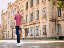
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
			<td>
        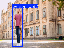
      </td>
      <td align=""center>
        <font size="96px">
        &#11015;
        </font>
      </td>
			<td>
        Дискриминативная нейросеть
      </td>
      <td>
        <img src="" />
      </td>
      <td>
        <img src="" />
      </td>
		</tr>
		<tr>
			<td>
        <img src="" />
      </td>
      <td>
      Генеративная нейросеть
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        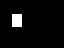
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
      <td>
        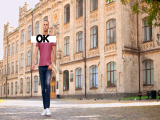
      </td>
		</tr>
</table>

In [ ]:
!pip install ultralytics gdown tqdm -qqq

from IPython import display
display.clear_output()
import ultralytics
ultralytics.checks()
from ultralytics import YOLO

from IPython.display import display, clear_output, Image
import os
import gdown
import cv2

In [ ]:
import gdown; from IPython.display import Video, Image
gdrive_url = 'https://drive.google.com/uc?export=download&id=1aNzbaXvasI1Ealcq3m-0mBGPpRvrJs70'
gdown.download(gdrive_url, quiet=True); Video("/content/HW8_building_and_person.mp4",embed=True, width=640, height=360)

In [ ]:
gdrive_url = 'https://drive.google.com/uc?export=download&id=1wKODx-KPHgSnY6HttStOXJZa3Fr6vBZn'
gdown.download(gdrive_url, quiet=True); Image("/content/HW8_building_and_person_processed.gif", width=640, height=360)

In [ ]:
%%capture
!apt-get update
!apt-get install -y redis-server
!redis-server --daemonize yes # Запуск Redis в фоновом режиме
!redis-server --version
!pip install 'faststream[redis]' asyncio

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm
import nest_asyncio
nest_asyncio.apply()
from faststream import FastStream
from faststream.redis import RedisBroker
import asyncio

model = YOLO("yolo11n.pt")          #стратегия загрузки Warm

output_video_path = '/content/building_and_person-processed.mp4'
video_file_path = "/content/HW8_building_and_person.mp4"
video_capture = cv2.VideoCapture(video_file_path)

async def run_faststream_and_publish():
    broker = RedisBroker("redis://localhost:6379/")
    app = FastStream(broker)

    @broker.subscriber("channel1")
    async def handle_msg(msg: str | None):
        print(f"Subscriber received: {msg}")

    @broker.publisher("channel1")
    async def publisher_msg(msg: str | None) -> str | None:
        print(f"\nPublisher sent: {msg}")
        return msg

    consumer_task = asyncio.create_task(app.start())
    publisher_task = asyncio.create_task(app.start())

    await asyncio.sleep(1) # Give brokers time to start

    if not video_capture.isOpened():
        print("Error: Could not open video file.")
    else:
        fps = int(video_capture.get(cv2.CAP_PROP_FPS))
        width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
        black_mask = np.zeros((height, width, 3), dtype=np.uint8)
        frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

        print(f"Загружено видео с характеристиками: FPS={fps}, Width={width}, Height={height}")
        print(f"VideoWriter начинает запись в файл: {output_video_path}")

        video_capture.set(cv2.CAP_PROP_POS_FRAMES, 0)
        with tqdm(total=frame_count, desc="обработано ") as pbar:
          while video_capture.isOpened():
              ret, frame = video_capture.read()
              if not ret:
                  break
              pbar.update(1)

              results = model(frame)
              annotated_frame = results[0].plot()
              await publisher_msg("<-новый кадр")

              image_with_box = frame.copy()

              for result in results:
                  xywh = result.boxes.xywh  # center-x, center-y, width, height
                  names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
                  if 'person' in names:
                      index = names.index('person')
                      x_center, y_center, box_w, box_h = map(int, xywh[index].tolist())

                      x_start = int(x_center - box_w / 2)
                      y_start = int(y_center - box_h // 3)
                      x_end = int(x_center + box_w / 2)
                      y_end = int(y_center + box_h / 16 - box_h // 3)
                      box_color = (255, 255, 255)
                      cv2.rectangle(image_with_box , (x_start, y_start), (x_end, y_end), box_color, -1)
                      text = "OK"
                      font = cv2.FONT_HERSHEY_SIMPLEX
                      font_scale = 0.6
                      font_thickness = 2
                      text_color = (0, 0, 0)

                      (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)

                      text_x =  (x_start + x_end) //2 - ( text_width) // 2
                      text_y =  (y_start + y_end) //2 +5

                      cv2.putText(image_with_box, text, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

              video_writer.write(image_with_box)

        video_capture.release()
        video_writer.release()

    # Cancel tasks to properly stop the FastStream apps
    consumer_task.cancel()
    publisher_task.cancel()

    try:
        await consumer_task
        await publisher_task
    except asyncio.CancelledError:
        print("FastStream applications stopped.")

asyncio.run(run_faststream_and_publish())



print(f"\nVideoWriter записал видео в файл {output_video_path}")

In [ ]:
%%html
<div class="mermaid">
flowchart LR
    subgraph Client ["Клиентская сторона"]
        direction TB
        VideoSrc[("/content/video.mp4<br/>Исходный поток")]
        Player[("Video Writer<br/>Результат")]
    end

    subgraph Ingestion ["Ingestion (FastStream)"]
        Splitter(Frame Splitter)
        RedisRaw[("Redis Stream<br/>Channel: input")]
    end

    subgraph Processing ["Processing Unit (Worker)"]
        direction TB
        YOLO["Discriminative Model<br/>(YOLOv11 - Detection)"]
        Coord["Logic<br/>(Calc Chest ROI)"]
        GenAI["Generative Model<br/>(Inpaint Brand Logo)"]
    end

    subgraph Serving ["Serving Layer"]
        RedisProc[("Redis Stream<br/>Channel: output")]
        Assembler(Stream Assembler)
    end

    %% Data Flow
    VideoSrc --> Splitter
    Splitter -->|Push Frames| RedisRaw
    RedisRaw -.->|Subscribe| YOLO
    YOLO -->|BBox Data| Coord
    Coord -->|Mask| GenAI
    GenAI -->|Overlay Frame| RedisProc
    RedisProc -.->|Publish| Assembler
    Assembler --> Player

    classDef storage fill:#f9f,stroke:#333,stroke-width:2px;
    classDef model fill:#bbf,stroke:#333,stroke-width:2px;
    class RedisRaw,RedisProc storage;
    class YOLO,GenAI model;
</div>

<script type="module">
    import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
    mermaid.initialize({ startOnLoad: true });
</script>